# Progetto d'esame

**Programmazione di Applicazioni Data Intensive**  
Laurea in Ingegneria e Scienze Informatiche  
DISI - Università di Bologna, Cesena

Studente: Luca Pulga
`luca.pulga@studio.unibo.it`

# Descrizione del problema

Il **Morbo di Parkinson** è una malattia neurodegenerativa progressiva che colpisce il sistema nervoso centrale, compromettendo principalmente il controllo dei movimenti. È la seconda malattia neurodegenerativa più comune al mondo dopo l'Alzheimer, con oltre 10 milioni di persone affette a livello globale.

Uno dei sintomi più caratteristici e rilevabili precocemente della malattia di Parkinson sono le **alterazioni vocali**: i pazienti sviluppano disfonie progressive causate dalla rigidità muscolare a livello laringeo e dalla ridotta capacità di controllo motorio fine. Queste alterazioni sono misurabili tramite parametri biomedici estratti da registrazioni vocali.

Il dataset in esame, noto come **UCI Parkinson's Dataset** (Little et al., 2007), contiene misurazioni biomediche della voce di **390 soggetti**, di cui 294 affetti da Parkinson e 96 sani. L'obiettivo del progetto è **predire la presenza o assenza del Morbo di Parkinson** a partire da queste misurazioni vocali.

Si tratta quindi di un problema di **classificazione binaria**.

> E' possibile apprezzare il dataset al link qui riportato: https://archive.ics.uci.edu/dataset/174/parkinsons

> Riferimento: Max A. Little, Patrick E. McSharry, Eric J. Hunter, Lorraine O. Ramig (2008), 'Suitability of dysphonia measurements for telemonitoring of Parkinson's disease', IEEE Transactions on Biomedical Engineering.


### Fonti

Vengono riportati alcuni video come fonte riguardo l'apprendimento del funzionamento del Morbo di Parkinson a livello biomolecolare:

**Understanding Parkinson's disease**
https://www.youtube.com/watch?v=ckn9zybpYZ8

**Malattia di Parkinson: cosa succede nel nostro cervello?**
https://www.youtube.com/watch?v=g4k6GItV33s


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    url = "https://raw.githubusercontent.com/PulgaLuca/Parkinson_Disease_Data_Intensive/main/parkinsons.data"
    dataset = pd.read_csv(url)

    print("Dataset caricato da GitHub")
except Exception as e:
    print(e)

print(dataset.shape)

Dataset caricato da GitHub
(390, 24)


# Data Exploration

In [2]:
dataset.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


Tutte le features disponibili all'interno del dataset sono **continue** e rappresentano misurazioni biometriche della voce.

Si riporta qui di seguito il Glossario con cui possiamo intepretare le feature che andremo ad analizzare:

#### Glossario
- MDVP: Multi-Dimensional Voice Program
- Jitter: variazioni ciclo-per-ciclo della frequenza fondamentale - variazioni del Pitch
- Shimmer: variazioni ciclo-per-ciclo dell’ampiezza del segnale vocale


Nello specifico, le **features** disponibili sono:

1. **name**
    - Identificativo del paziente
    - `stringa`

#### Frequenza Fondamentale (MDVP)
2. **MDVP:Fo(Hz)** (Fundamental Frequency)
    - Frequenza fondamentale media della voce
    - Misura quante vibrazioni al secondo fanno le corde vocali
    - `float (Hz)`
3. **MDVP:Fhi(Hz)** (Highest Fundamental Frequency)
    - Frequenza fondamentale massima
    - `float (Hz)`
4. **MDVP:Flo(Hz)** (Lowest Fundamental Frequency)
    - Frequenza fondamentale minima
    - `float (Hz)`



#### Variazioni del Pitch (Jitter)
5. **MDVP:Jitter(%)**
    - Variazione del periodo di pitch (%)
    - `float`
6. **MDVP:Jitter(Abs)** (Absolute Jitter)
    - Variazione assoluta del periodo di pitch
    - È una misura di instabilità molto fine
    - `float`
7. **MDVP:RAP** (Relative Average Perturbation)
    - Rapporto di perturbazione relativa, media delle variazioni relative su 3 periodi consecutivi
    - `float`
8. **MDVP:PPQ** (Pitch Perturbation Quotient)
    - Quoziente di perturbazione del pitch su 5 periodi
    - `float`
9. **Jitter:DDP** (Difference of Differences of Periods)
    - Media delle differenze assolute tra cicli successivi
    - `float`



#### Variazioni dell’Ampiezza (Shimmer)
10. **MDVP:Shimmer**
    - Variazione dell'ampiezza locale
    - `float`
11. **MDVP:Shimmer(dB)**
    - Variazione dell'ampiezza in dB
    - `float`
12. **Shimmer:APQ3** (Amplitude Perturbation Quotient – 3 periods)
    - Quoziente di perturbazione dell'ampiezza su 3 cicli
    - `float`
13. **Shimmer:APQ5** (Amplitude Perturbation Quotient – 5 periods)
    - Quoziente di perturbazione dell'ampiezza su 5 cicli
    - `float`
14. **MDVP:APQ** (Amplitude Perturbation Quotient)
    - Quoziente di perturbazione dell'ampiezza MDVP
    - `float`
15. **Shimmer:DDA** (Average Absolute Differences of Amplitudes)
    - Media delle differenze tra ampiezze consecutive
    - `float`


#### Rapporto Rumore/Armoniche
16. **NHR** (Noise-to-Harmonics Ratio)
    - Rapporto rumore/armonia
    - Indica quanto il segnale vocale è pulito
    - `float`
17. **HNR** (Harmonics-to-Noise Ratio)
    - Rapporto armonia/rumore
    - `float`
  

#### Misure non lineari
18. **RPDE** (Recurrence Period Density Entropy)
    - Entropia dinamica ricorrente non lineare
    - `float`
19. **DFA** (Detrended Fluctuation Analysis)
    - Analisi delle fluttuazioni detrended
    - `float`
20. **spread1**
    - Misura non lineare della variazione della frequenza fondamentale
    - `float`
21. **spread2**
    - Misura non lineare della variazione della frequenza fondamentale
    - `float`
22. **D2** (Correlation Dimension)
    - Correlazione dimensionale non lineare
    - `float`
23. **PPE** (Pitch Period Entropy)
    - Entropia del periodo di pitch
    - `float`


#### Variabile Target
24. **status**
- **Variabile target binaria**
    - 1: Malato di Parkinson
    - 0: Sano

La variabile target è **`status`**, la quale è **binaria**: `1` indica la presenza del Morbo di Parkinson, `0` indica assenza di malattia.

In [3]:
dataset.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,...,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000
mean,151.900242,196.284112,114.521559,0.006281,0.000045,0.003327,0.003483,0.009981,0.030060,0.284200,...,0.047584,0.025003,21.803268,0.753846,0.503852,0.718172,-5.641548,0.227347,2.374076,0.209998
std,40.498682,90.769325,42.659872,0.004384,0.000033,0.002689,0.002462,0.008068,0.017305,0.174300,...,0.028252,0.037093,4.070450,0.431323,0.098158,0.053242,1.022196,0.077310,0.347705,0.084594
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.116486,134.315326,82.709680,0.003690,0.000027,0.001690,0.001941,0.005072,0.017088,0.155000,...,0.025702,0.006329,19.310861,1.000000,0.430166,0.675169,-6.357705,0.173282,2.133349,0.144232
50%,148.095907,165.363500,103.539650,0.005195,0.000040,0.002639,0.002920,0.007917,0.024577,0.234000,...,0.040630,0.013514,21.836023,1.000000,0.497209,0.720912,-5.646237,0.224034,2.360753,0.208728
75%,177.914392,221.290685,133.645705,0.007411,0.000060,0.003824,0.003980,0.011469,0.039843,0.363709,...,0.062105,0.026356,24.913750,1.000000,0.589595,0.761140,-4.970308,0.281236,2.592242,0.259953
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


Dalla descrizione statistica del dataset possiamo osservare che le features presentano scale molto diverse tra loro. Per esempio:
- `MDVP:Fo(Hz)` varia tra circa 88 e 260 Hz
  - Valori bassi (~88 Hz) = voce più grave
  - Valori alti (~260 Hz) = voce più acuta
- `MDVP:Jitter(Abs)` ha valori nell'ordine di 10⁻⁵
  - Valori molto piccoli = voce stabile
  - Valori più grandi = maggiore irregolarità (tipica nel Parkinson)
- `HNR` raggiunge valori fino a 33
  - Valori alti (~30+) = voce chiara, stabile
  - Valori bassi = voce più rumorosa e disordinata

Questa eterogeneità di scala rende **necessaria una normalizzazione** prima di applicare modelli, in particolare per algoritmi sensibili alle scale come Perceptron, Logistic Regression e SVM.

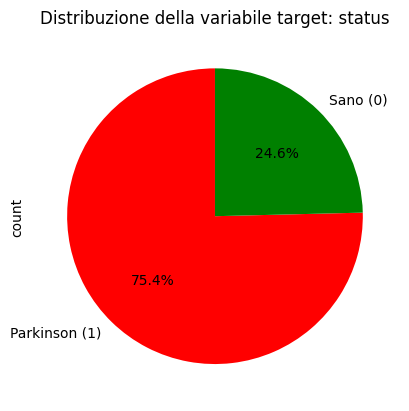

In [4]:
plt.title('Distribuzione della variabile target: status')
plt.ylabel('')
dataset['status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Parkinson (1)', 'Sano (0)'],
    colors=['red', 'green'],
    startangle=90
)
plt.show()

Osservando il grafico a torta, la variabile target `status` risulta **sbilanciata**: circa il **75%** dei soggetti è malato da Morbo di Parkinson e il **25%** è sano. Questo squilibrio è intrinseco nella natura del dataset, in quanto è un campione clinico, e dovrà essere tenuto in considerazione nella valutazione dei modelli, privilegiando metriche come **F1-score** e **precision/recall** rispetto alla sola accuracy.

### Rilevazione di valori nulli

Si rilevano, se presenti, valori nulli nel dataset.

In [5]:
dataset.isna().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


Il dataset non presenta valori nulli.

# Data Cleaning

In questa sezione andiamo a rimuovere o manipolare i dati che potrebbero alterare l'efficacia del modello o che risultano semanticamente inconsistenti.

La colonna `name` è un identificativo del paziente, non ha valore significativo e non ha valore predittivo, quindi verrà rimossa.
Tutte le restanti features sono **continue** e rappresentano misurazioni biomediche della voce necessarie all'analisi che verrà condotta.


In [6]:
dataset = dataset.drop(columns=['name'], errors='ignore')
dataset.columns

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

Alcuni vincoli fisici devono essere rispettati, come da letteratura nell'ambito medico, ovvero:
- la **frequenza fondamentale** della voce non può essere negativa
- il **jitter** e lo **shimmer** non possono essere negativi
- il rapporto **HNR** (Harmonic to Noise Ratio) deve essere positivo

In [7]:
# Controllo dei parametri sopra descritti
freq_cols = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)']
for col in freq_cols:
    n_neg = dataset[dataset[col]<=0].shape[0]
    print(f"Valori non positivi in '{col}': {n_neg}")

Valori non positivi in 'MDVP:Fo(Hz)': 0
Valori non positivi in 'MDVP:Fhi(Hz)': 0
Valori non positivi in 'MDVP:Flo(Hz)': 0


In [8]:
# verifichiamo che la frequenza minima non superi quella massima, sempre per vincolo fisico ovviamente
inconsistent = dataset[dataset['MDVP:Flo(Hz)'] > dataset['MDVP:Fhi(Hz)']].shape[0]
print(f"Casi in cui Flo > Fhi (è fisicamente inconsistente): {inconsistent}")

Casi in cui Flo > Fhi (è fisicamente inconsistente): 0


Non si rilevano inconsistenze fisiche nel dataset. Procediamo comunque con la rimozione di outlier estremi applicando un filtraggio basato sui quantili (2.5% - 97.5%) per le features di frequenza, analogamente a quanto fatto nel progetto di riferimento.

In [9]:
print(f"Dimensione dataset prima del cleaning: {dataset.shape}")

# Rimozione outlier per le misure di frequenza fondamentale
for col in freq_cols:
    q_low = dataset[col].quantile(0.025)
    q_hi  = dataset[col].quantile(0.975)
    dataset.drop(dataset[(dataset[col] > q_hi) | (dataset[col] < q_low)].index, inplace=True)

print(f"Dimensione dataset dopo il cleaning: {dataset.shape}")

Dimensione dataset prima del cleaning: (390, 23)
Dimensione dataset dopo il cleaning: (332, 23)


In [10]:
dataset.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,...,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000
mean,150.667456,188.220585,111.633416,0.006225,0.000044,0.003264,0.003459,0.009792,0.030143,0.285261,...,0.047413,0.024537,21.866371,0.777108,0.501815,0.719659,-5.612338,0.231529,2.381090,0.211253
std,35.031993,71.310511,35.302251,0.004230,0.000032,0.002601,0.002414,0.007803,0.017431,0.174954,...,0.028267,0.035279,4.230149,0.416814,0.099277,0.051179,1.006426,0.075368,0.362111,0.083156
min,95.730000,113.597000,66.890293,0.001680,0.000009,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.263654,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,118.722489,135.807664,82.632237,0.003737,0.000030,0.001690,0.001983,0.005067,0.017072,0.155000,...,0.025362,0.006200,19.202878,1.000000,0.428857,0.679482,-6.262211,0.181723,2.128848,0.149394
50%,148.637745,163.907638,104.580660,0.005162,0.000037,0.002580,0.002894,0.007735,0.024487,0.232775,...,0.040287,0.014159,21.818000,1.000000,0.490206,0.720912,-5.664532,0.227358,2.364057,0.207202
75%,176.624745,211.754603,132.602468,0.007402,0.000051,0.003767,0.003965,0.011293,0.039960,0.366725,...,0.062464,0.026436,25.123000,1.000000,0.592462,0.759211,-4.936804,0.283996,2.627608,0.255285
max,240.301000,492.892000,221.156000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


Dopo la pulizia dei dati i valori delle features appaiono coerenti. I valori di frequenza fondamentale si attestano su range fisiologicamente plausibili per la voce umana adulta.

# Data Exploration

Andiamo a visualizzare le distribuzioni delle principali features continue del dataset.

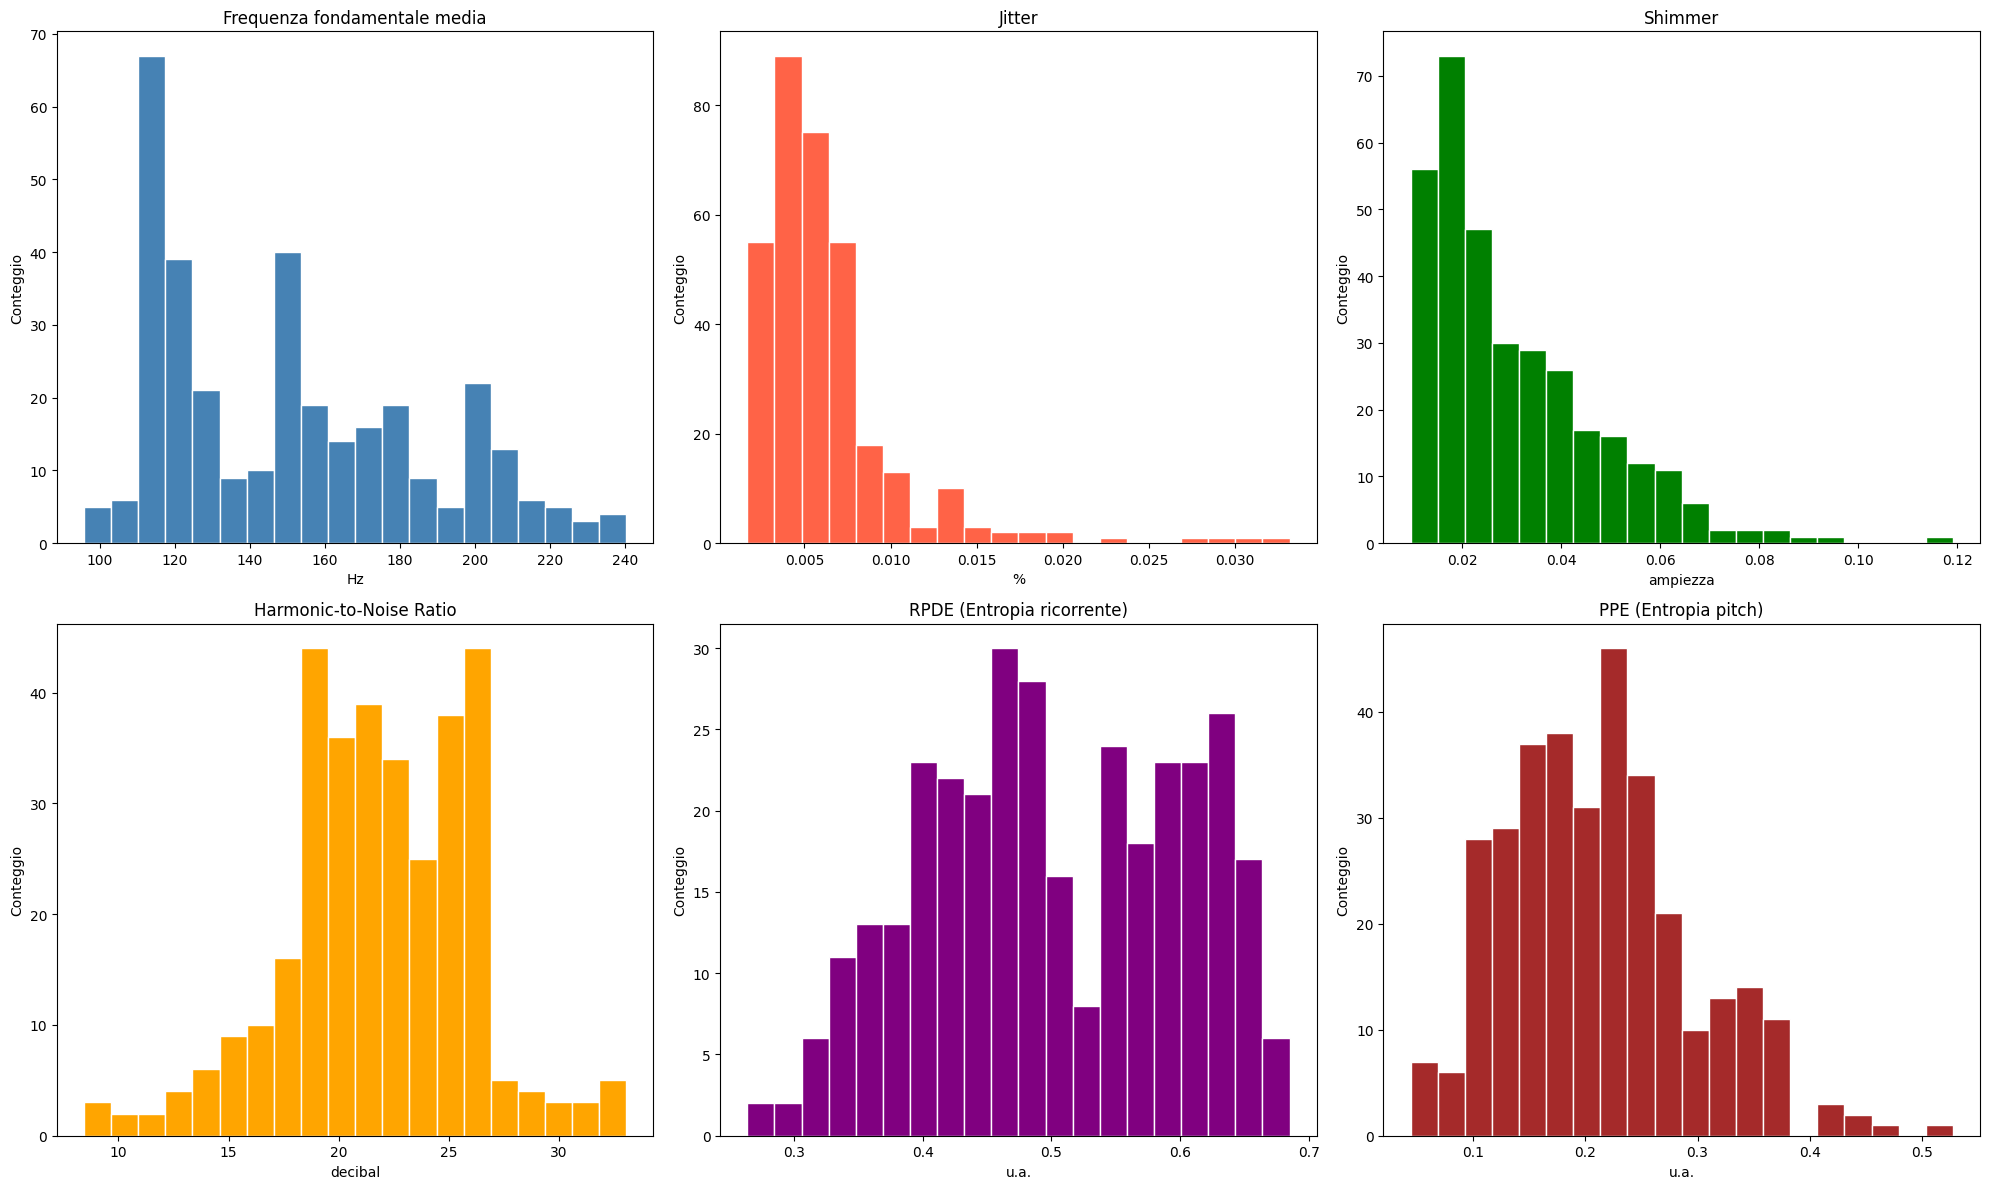

In [11]:
plt.figure(figsize=(20, 12))

features_to_plot = [
    ('MDVP:Fo(Hz)', 'Hz', 'Frequenza fondamentale media', 'steelblue'),
    ('MDVP:Jitter(%)', '%', 'Jitter', 'tomato'),
    ('MDVP:Shimmer', 'ampiezza', 'Shimmer', 'green'),
    ('HNR', 'decibal', 'Harmonic-to-Noise Ratio', 'orange'),
    ('RPDE', 'u.a.', 'RPDE (Entropia ricorrente)', 'purple'),
    ('PPE', 'u.a.', 'PPE (Entropia pitch)', 'brown'),
]

for i, (col, unit, title, color) in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    plt.title(title)
    plt.hist(dataset[col].squeeze(), color=color, edgecolor='white', bins=20)
    plt.ylabel('Conteggio')
    plt.xlabel(unit)

plt.tight_layout()
plt.show()

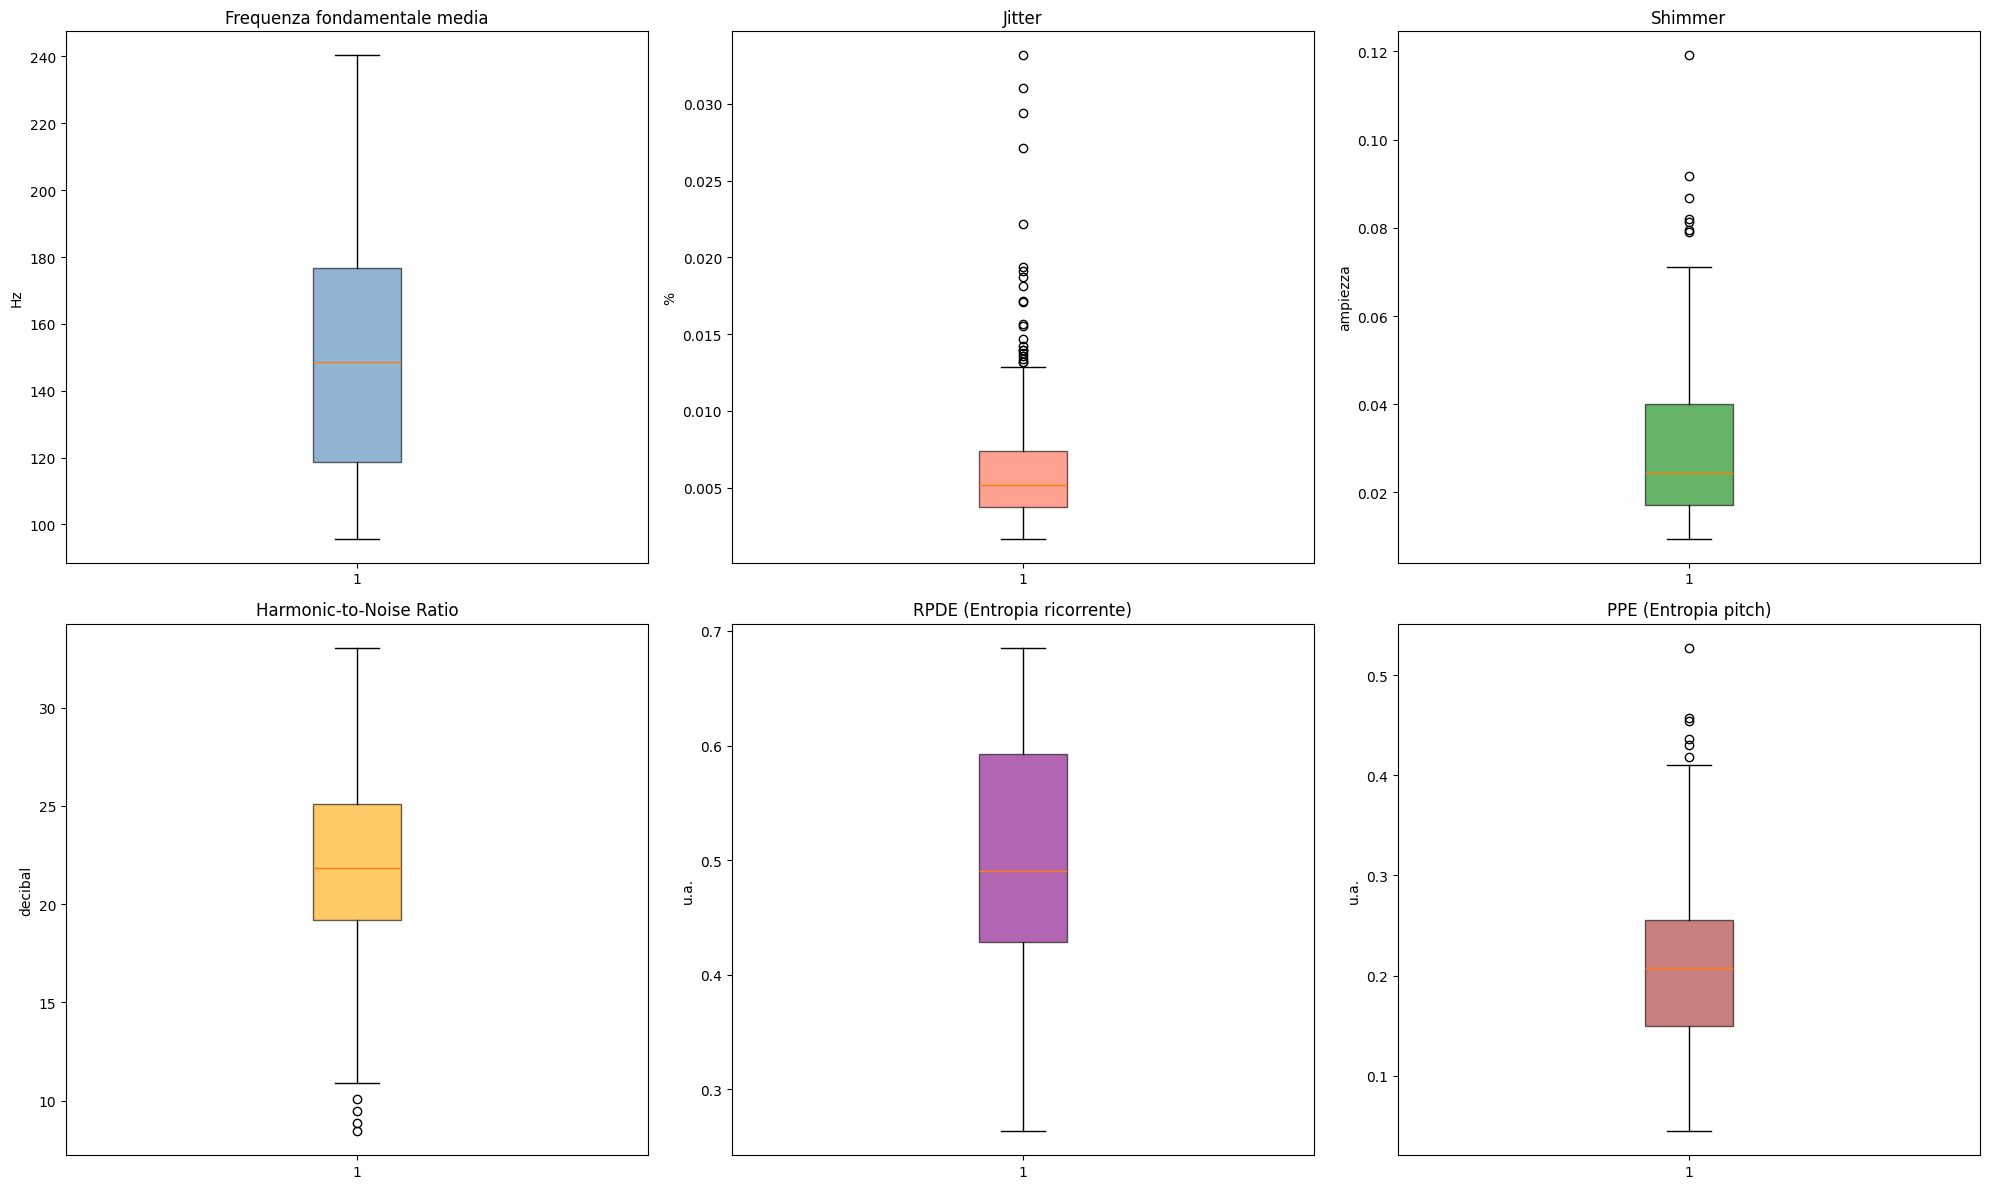

In [12]:
plt.figure(figsize=(20, 12))

for i, (col, unit, title, color) in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    plt.title(title)
    plt.boxplot(dataset[col], patch_artist=True, boxprops=dict(facecolor=color, alpha=0.6))
    plt.ylabel(unit)

plt.tight_layout()
plt.show()

Osservando gli istogrammi e i boxplot, si nota che molte features relative al **jitter** e allo **shimmer** presentano una distribuzione asimmetrica verso destra (ovvero sono right-skewed), tipica di misurazioni di perturbazione che si concentrano vicino allo zero ma con code più pesanti nei pazienti con Parkinson.
Il **HNR** mostra una distribuzione bimodale che suggerisce una separazione tra i soggetti sani (HNR più alto) e quelli malati (HNR più basso).

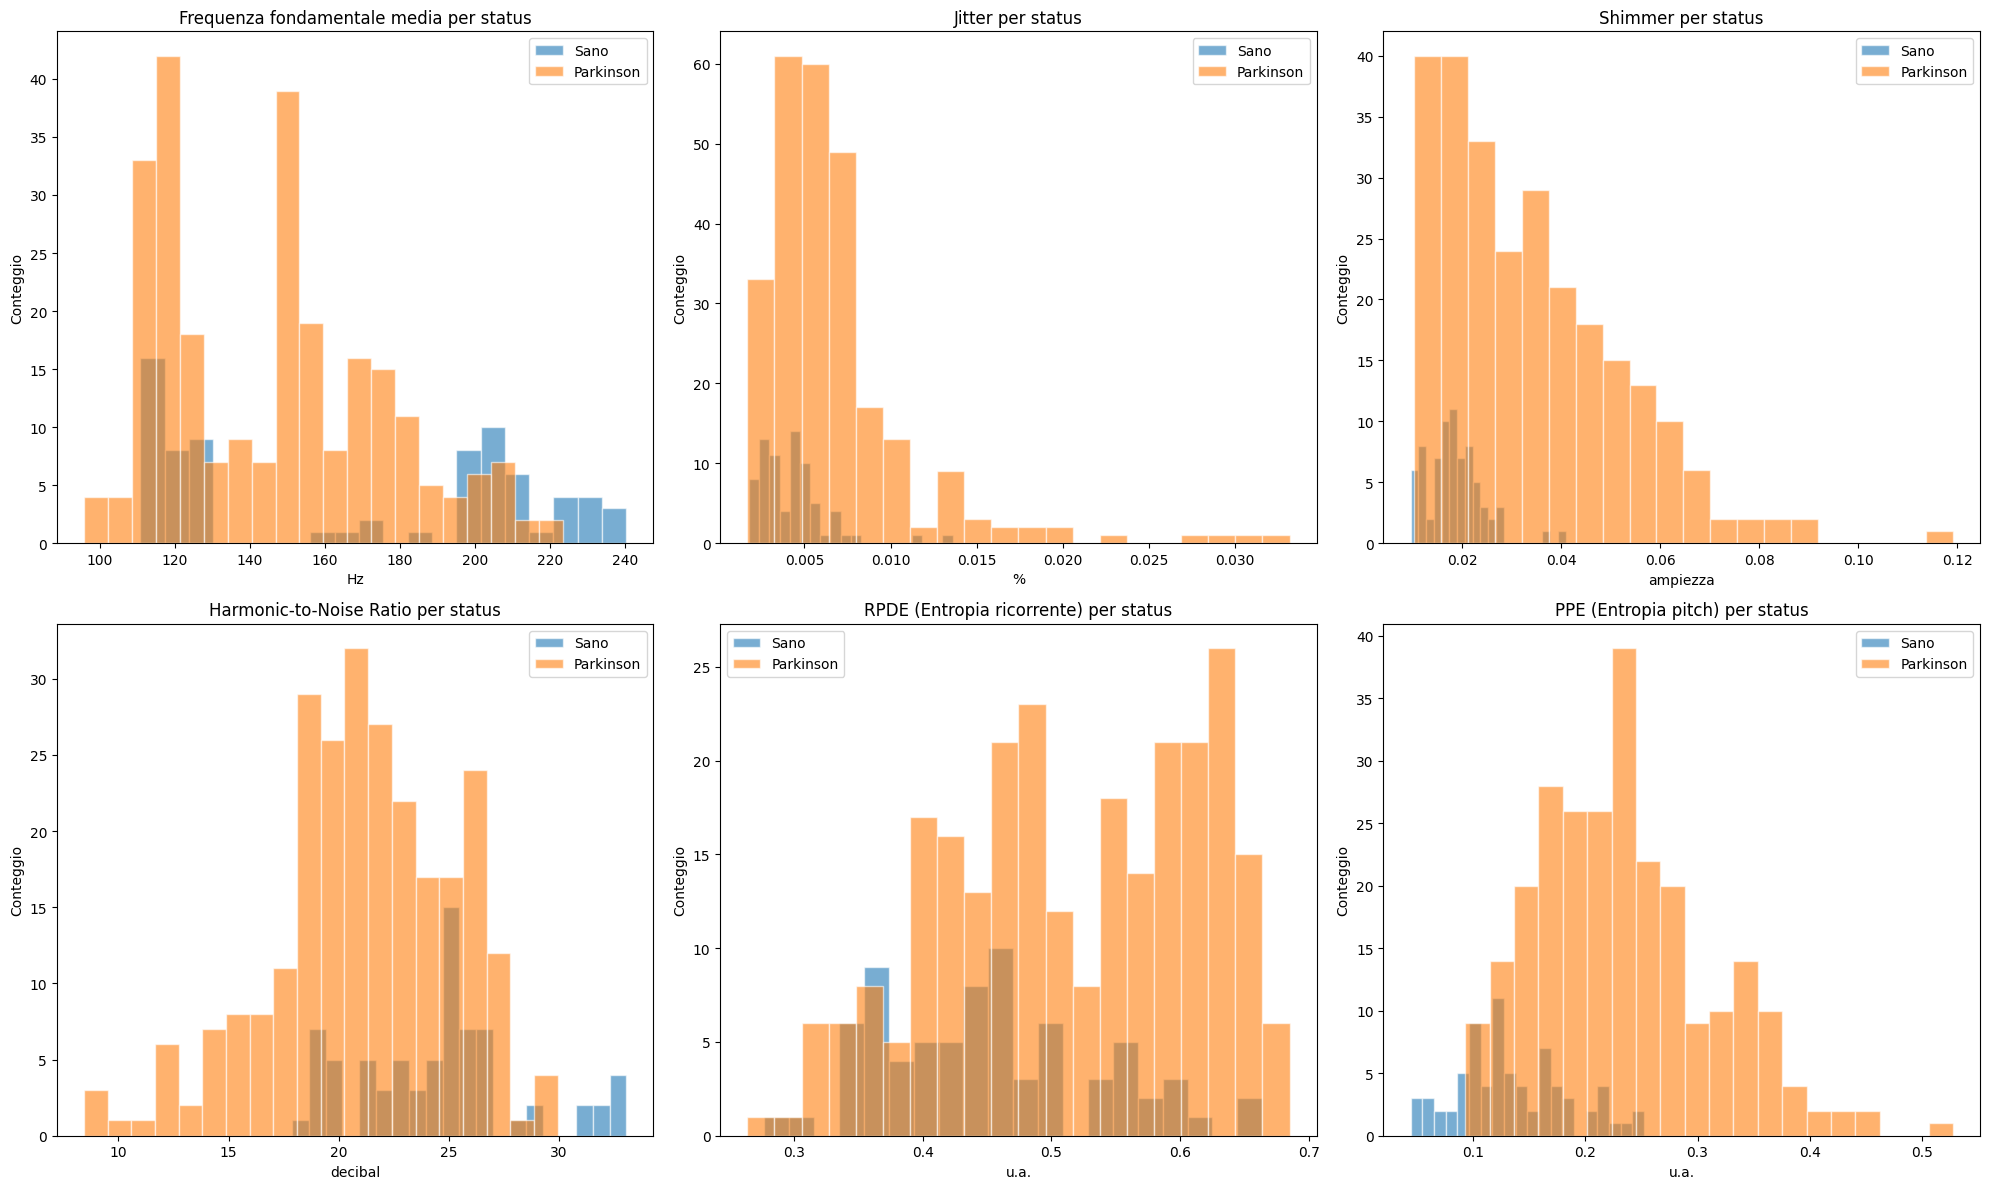

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (col, unit, title, color) in enumerate(features_to_plot):
    axes[i].set_title(f'{title} per status')
    for status, grp in dataset.groupby('status'):
        label = 'Parkinson' if status == 1 else 'Sano'
        axes[i].hist(grp[col], alpha=0.6, bins=20, label=label, edgecolor='white')
    axes[i].set_xlabel(unit)
    axes[i].set_ylabel('Conteggio')
    axes[i].legend()

plt.tight_layout()
plt.show()

Visualizzando la distribuzione delle features separata per status, emerge chiaramente che:
- **MDVP:Fo(Hz)**: i soggetti sani tendono ad avere una frequenza fondamentale più stabile e nella media, mentre i pazienti con Parkinson mostrano maggiore variabilità.
- **Jitter e Shimmer**: valori più elevati sono associati ai pazienti con Parkinson, confermando la loro utilità come biomarcatori della disfonia.
- **HNR**: i soggetti sani presentano in media un HNR più alto (voce più armoniosa), mentre i pazienti con Parkinson mostrano un HNR ridotto (maggiore componente di rumore).
- **RPDE e PPE**: entrambe le misure di complessità non lineare sono più alte nei pazienti con Parkinson.

In [14]:
def plot_correlation(data):
    cmap = sns.diverging_palette(220, 10, as_cmap=True) # colormap divergente, blu <-> rosso
    mask = np.zeros_like(data, dtype=bool)
    mask[np.triu_indices_from(mask)] = True # nasconde triangolo superiore visto che simmetrica
    f, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(data, mask=mask, cmap=cmap, vmax=.6, center=0, annot=True, fmt='.2f', square=True,
                linewidths=.5, cbar_kws={"shrink": .5}, annot_kws={"size": 7})
    plt.title('Matrice di correlazione', fontsize=14)
    plt.tight_layout()
    plt.show()

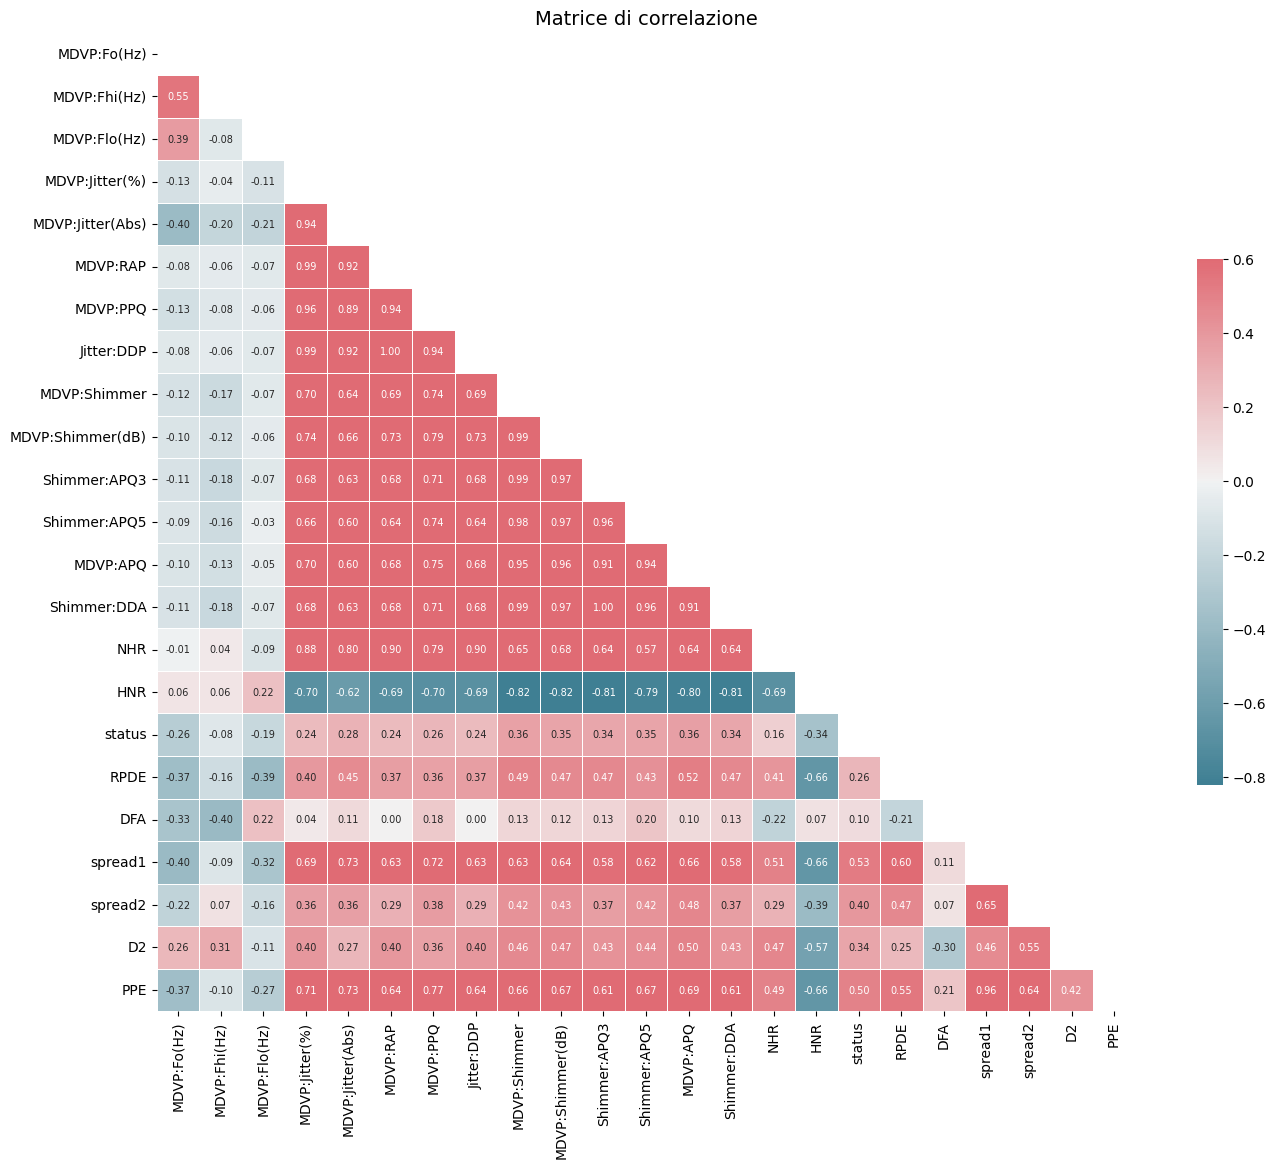

In [15]:
plot_correlation(dataset.corr())

Dalla matrice di correlazione emergono diverse correlazioni interessanti:

* **gruppo Jitter** (`MDVP:Jitter(%)`, `MDVP:RAP`, `MDVP:PPQ`, `Jitter:DDP`): queste features sono altamente correlate tra loro (correlazione > 0.9), in quanto rappresentano variazioni dello stesso fenomeno fisico (instabilità del periodo di pitch) misurate con metodi leggermente diversi.
* **gruppo Shimmer** (`MDVP:Shimmer`, `MDVP:Shimmer(dB)`, `Shimmer:APQ3`, `Shimmer:APQ5`, `Shimmer:DDA`): analogamente, le misure di shimmer sono fortemente correlate tra loro.
* **Jitter vs Shimmer**: esiste una correlazione positiva moderata tra le misure di jitter e quelle di shimmer, suggerendo che instabilità nel pitch e nell'ampiezza tendono a verificarsi simulataneamente.
* **`status` vs `spread1`, `PPE`, `RPDE`**: **le misure non lineari** mostrano la **correlazione più alta con la variabile target**, suggerendo che i modelli non lineari della dinamica vocale siano i più informativi per la diagnosi.
* **`HNR` vs `status`**: correlazione negativa, ovvero un HNR più basso è associato alla presenza di Parkinson.


# Features Engineering

> Con questa tecnica si introducono features che non erano presenti originariamente nel dataset. Le features aggiunte sono derivate direttamente o indirettamente dalle features già a disposizione.

Nel contesto della analisi vocale per il Parkinson, è possibile derivare alcune features aggregate:

1. **Jitter medio**: media aritmetica delle principali misure di jitter, che sintetizza l'instabilità del pitch.
$$\text{mean_jitter} = \frac{\text{Jitter}(\%) + \text{RAP} + \text{PPQ}}{3}$$

2. **Shimmer medio**: media delle principali misure di shimmer, che sintetizza l'instabilità dell'ampiezza.
$$\text{mean_shimmer} = \frac{\text{Shimmer} + \text{APQ3} + \text{APQ5}}{3}$$

3. **Range frequenza fondamentale**: differenza tra frequenza massima e minima, indicatore di escursione tonale.
$$\text{freq_range} = \text{Fhi} - \text{Flo}$$

In [16]:
dataset['mean_jitter'] = (dataset['MDVP:Jitter(%)']+dataset['MDVP:RAP']+dataset['MDVP:PPQ'])/3

dataset['mean_shimmer'] = (dataset['MDVP:Shimmer']+dataset['Shimmer:APQ3']+dataset['Shimmer:APQ5'])/3

dataset['freq_range'] = dataset['MDVP:Fhi(Hz)']-dataset['MDVP:Flo(Hz)']

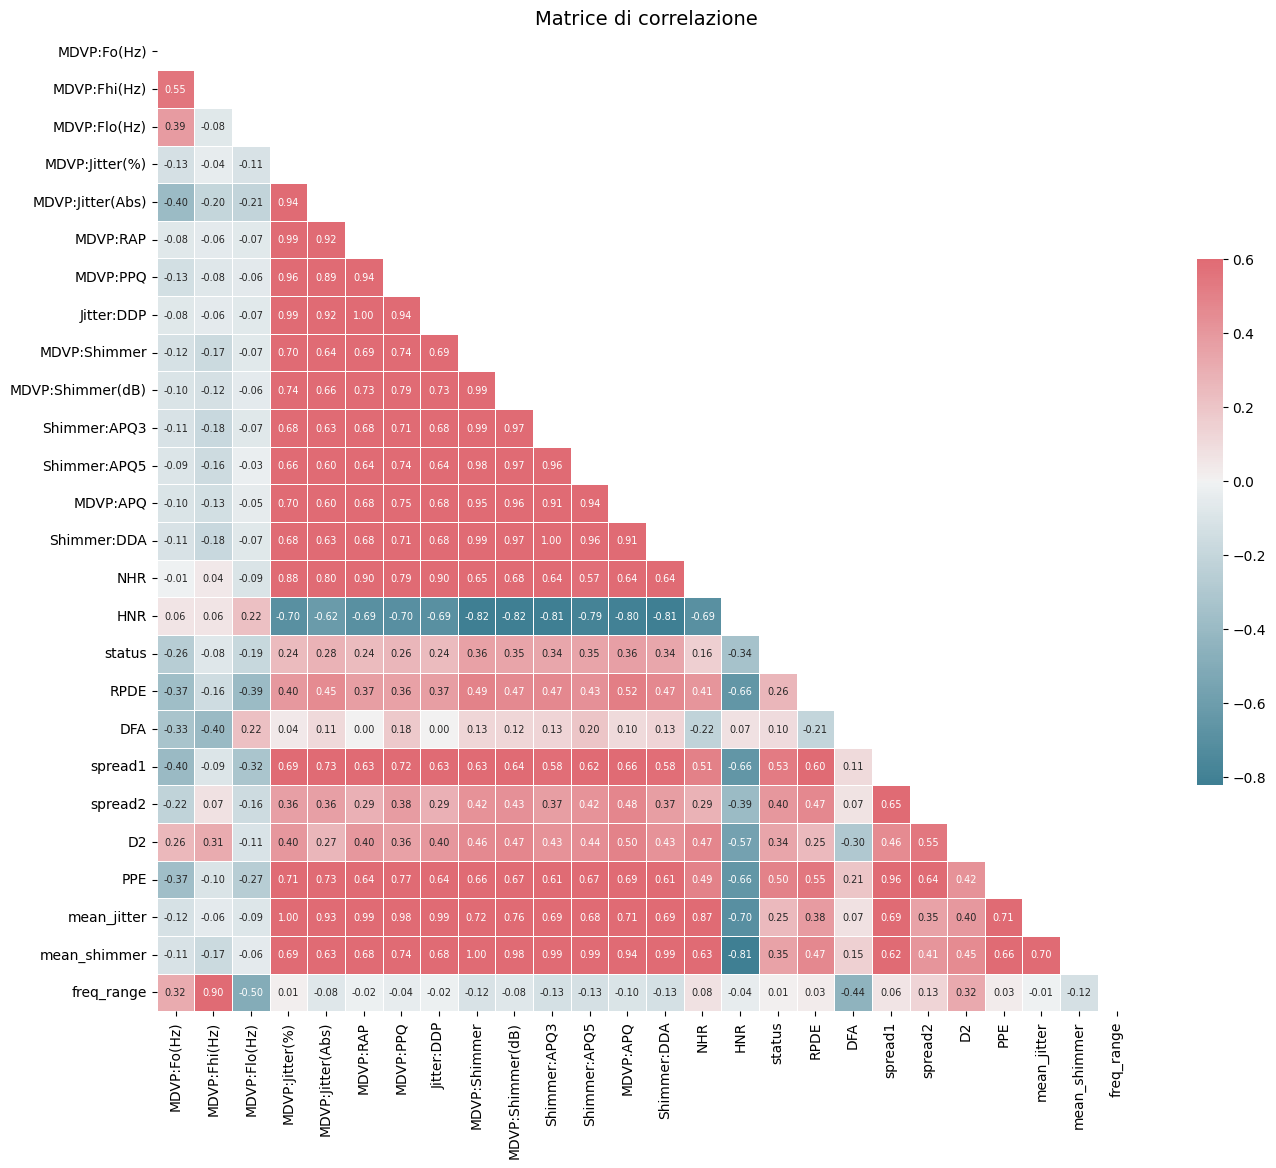

In [17]:
plot_correlation(dataset.corr())

Riproducendo la matrice di correlazione con le nuove features, si osserva che:
- `mean_jitter` e `mean_shimmer` presentano una correlazione con `status` comparabile o superiore alle singole misure originali, confermandone l'utilità come features sintetiche.
- `freq_range` aggiunge una prospettiva sull'escursione vocale non direttamente catturata dalle singole misure di frequenza.

**Non essendo presenti features categoriche nel dataset, non è necessario applicare tecniche di encoding come il one-hot encoding.**

In [18]:
X = dataset.drop('status', axis=1)
y = dataset['status']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y.values.ravel(),
    test_size=0.3,
    random_state=43,
    stratify=y.values
)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Validation set: {X_val.shape[0]} campioni")

Training set: 232 campioni
Validation set: 100 campioni


In [20]:
from statsmodels.stats.proportion import proportion_confint

def confidence_interval(instance, acc, confidence):
    return proportion_confint(instance*acc, instance, 1-confidence/100, method='wilson') # wilson, più robusto per proporzioni per costruire l’intervallo

In [21]:
def plot_confusion_matrix(cm, target_names, title='Confusion matrix', cmap=None, normalize=True):
    import itertools
    import numpy as np
    import matplotlib.pyplot as plt

    # global accuracy sarebbe la somma diagonale/tot elementi
    accuracy = np.trace(cm)/float(np.sum(cm))
    # errore
    misclass = 1-accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis] # normalizzazione per riga

    thresh = cm.max()/1.5 if normalize else cm.max()/2

    # iteriamo sulle celle della matrice
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            # valori normalizzati - probabilità
            plt.text(j, i,"{:0.4f}".format(cm[i, j]),horizontalalignment="center",color="white" if cm[i, j] > thresh else "black")
        else:
            # valori assoluti - conteggi
            plt.text(j, i,"{:,}".format(cm[i, j]),horizontalalignment="center",color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

# Perceptron

Il **Perceptron** è il modello lineare di classificazione più semplice. È un classificatore lineare che apprende aggiornando i pesi solo in caso di errore di classificazione. Pur nella sua semplicità, costituisce la base concettuale nelle reti neurali moderne.

In [22]:
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

std_perceptron = Pipeline([
    ('std', StandardScaler()),
    ('perceptron', Perceptron(max_iter=8000, tol=1e-3, early_stopping=True, alpha=0.0001, n_jobs=-1))
])

std_perceptron.fit(X_train, y_train)
print('Accuracy on train: {:.2f}%'.format(std_perceptron.score(X_train, y_train)*100))
print('Accuracy on val:   {:.2f}%'.format(std_perceptron.score(X_val, y_val)*100))

Accuracy on train: 79.74%
Accuracy on val:   75.00%


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

std_perceptron = Pipeline([
    ('std', StandardScaler()),
    ('perceptron', Perceptron(n_jobs=-1, early_stopping=True, n_iter_no_change=5))
])

parameters = {
    'std': [None, StandardScaler()],
    'perceptron__penalty': [None, 'l1', 'l2', 'elasticnet'],
    'perceptron__alpha': [0.0001, 0.001, 0.01, 1],
    'perceptron__tol': [1e-9, 1e-6, 1e-3, 1, 1e3, 1e6],
}

perceptron_cv = GridSearchCV(std_perceptron, parameters, cv=5, n_jobs=-1, scoring='f1')
perceptron_cv.fit(X_train, y_train)
print('GridSearch on Perceptron finished')

GridSearch on Perceptron finished


In [27]:
print('Best parameters:', perceptron_cv.best_params_) #quale combinazione di iperparametri ha funzionato meglio
# perceptron__alpha basso, dunque meno regolarizzazione, modello si può adattare ai dati più facilemente
print('Best score: {:.4f}%'.format(round(perceptron_cv.best_score_*100, 4))) # media della cross-validation accuracy

Best parameters: {'perceptron__alpha': 0.0001, 'perceptron__penalty': None, 'perceptron__tol': 1e-09, 'std': StandardScaler()}
Best score: 90.5484%


In [28]:
confidence = 95
lower, upper = confidence_interval(len(X_val), perceptron_cv.score(X_val, y_val), confidence)
print('Intervallo di confidenza {}%: \nPmin = {:.4f}%\nPmax = {:.4f}%'.format(confidence, lower*100, upper*100))

Intervallo di confidenza 95%: 
Pmin = 73.3487%
Pmax = 88.3114%


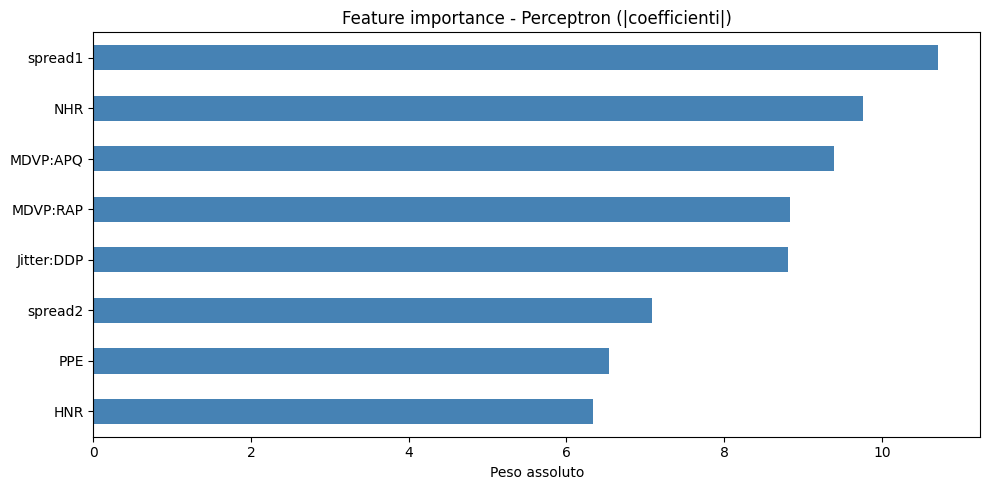

In [29]:
pc_imp = pd.Series(perceptron_cv.best_estimator_['perceptron'].coef_[0], index=X_train.columns)
pc_imp.abs().nlargest(8).sort_values().plot(kind='barh', color='steelblue', figsize=(10, 5))
plt.title('Feature importance - Perceptron (|coefficienti|)')
plt.xlabel('Peso assoluto')
plt.tight_layout()
plt.show()

Possiamo osservare che le features con maggiore peso nel modello Perceptron sono prevalentemente le misure non lineari (`spread1`, `PPE`, `RPDE`) e il rapporto armonia/rumore (`HNR`). Questo è coerente con la letteratura scientifica, che indica le misure di complessità non lineare come i predittori più potenti per la diagnosi del Parkinson basata sulla voce.

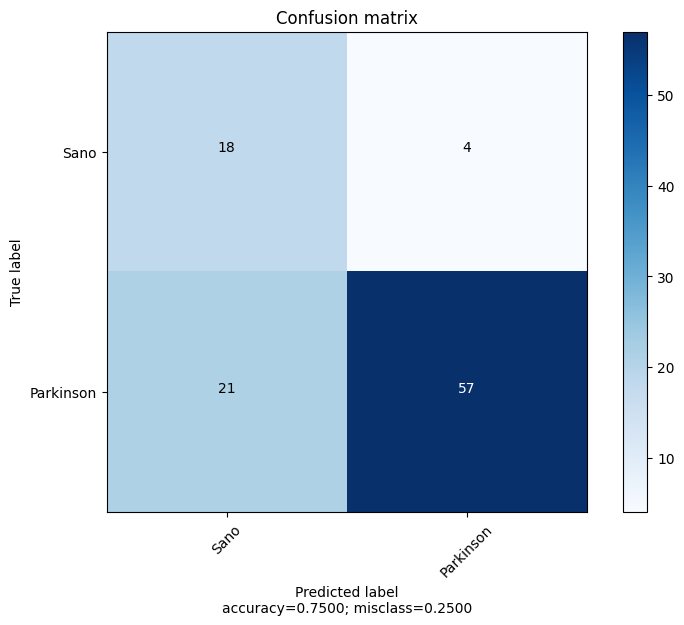

In [30]:
from sklearn.metrics import confusion_matrix

y_pred = perceptron_cv.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [31]:
pred = perceptron_cv.predict(X_val)
print(classification_report(y_val, pred, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.46      0.82      0.59        22
   Parkinson       0.93      0.73      0.82        78

    accuracy                           0.75       100
   macro avg       0.70      0.77      0.71       100
weighted avg       0.83      0.75      0.77       100



In [32]:
from sklearn.metrics import mean_squared_error

perc_mse = mean_squared_error(y_val, perceptron_cv.predict(X_val))
print('MSE Perceptron: {:.4f}'.format(perc_mse))

MSE Perceptron: 0.2500


### Perceptron con Polynomial Features

In [33]:
from sklearn.preprocessing import PolynomialFeatures

poly_perceptron = Pipeline([
    ('std', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('perceptron', Perceptron(n_jobs=-1, early_stopping=True, n_iter_no_change=5))
])

parameters = {
    'std': [None, StandardScaler()],
    'perceptron__penalty': ['l1', 'l2'],
    'perceptron__alpha': [0.0001, 0.001, 0.01],
    'perceptron__tol': [1e-9, 1e-6, 1e-3, 1],
}

poly_perceptron_cv = GridSearchCV(poly_perceptron, parameters, cv=5, n_jobs=-1,return_train_score=True, scoring='f1')
poly_perceptron_cv.fit(X_train, y_train)
print('GridSearch on Polynomial Perceptron finished')

GridSearch on Polynomial Perceptron finished


In [34]:
print('Best parameters:', poly_perceptron_cv.best_params_)
print('Best score: {:.4f}%'.format(round(poly_perceptron_cv.best_score_*100, 4)))

Best parameters: {'perceptron__alpha': 0.001, 'perceptron__penalty': 'l1', 'perceptron__tol': 1e-09, 'std': StandardScaler()}
Best score: 95.2755%


In [35]:
confidence = 95
lower, upper = confidence_interval(len(X_val), poly_perceptron_cv.score(X_val, y_val), confidence)
print('Intervallo di confidenza {}%: \nPmin = {:.4f}%\nPmax = {:.4f}%'.format(confidence, lower*100, upper*100))

Intervallo di confidenza 95%: 
Pmin = 91.1714%
Pmax = 98.8351%


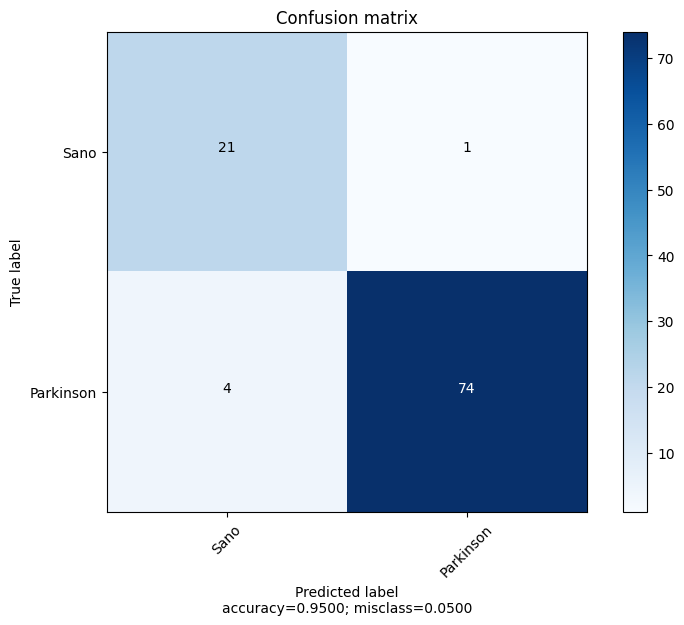

In [36]:
y_pred = poly_perceptron_cv.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [37]:
pred = poly_perceptron_cv.predict(X_val)
print(classification_report(y_val, pred, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.84      0.95      0.89        22
   Parkinson       0.99      0.95      0.97        78

    accuracy                           0.95       100
   macro avg       0.91      0.95      0.93       100
weighted avg       0.95      0.95      0.95       100



In [38]:
poly_mse = mean_squared_error(y_val, poly_perceptron_cv.predict(X_val))
print('MSE Polynomial Perceptron: {:.4f}'.format(poly_mse))

MSE Polynomial Perceptron: 0.0500


# Logistic Regression

La **Regressione Logistica** è un modello lineare di classificazione che stima la probabilità di appartenenza a una classe tramite la funzione sigmoide applicata a una combinazione lineare delle features.

In [39]:
from sklearn.linear_model import LogisticRegression

std_lr = Pipeline([
    ('std', StandardScaler()),
    ('lr', LogisticRegression(dual=False, max_iter=5000))
])

parameters = {
    'lr__penalty': ['l1', 'l2'],
    'lr__tol': [1e-9, 1e-6, 1e-3, 1e-2, 1e-1, 1],
    'lr__C': [0.01, 0.1, 0.5, 1, 5, 10],
    'lr__solver': ['liblinear']
}

lr_gs = GridSearchCV(std_lr, parameters, cv=5, n_jobs=-1, return_train_score=True, scoring='f1')
lr_gs.fit(X_train, y_train)
print('Grid search Logistic Regression finished')

Grid search Logistic Regression finished


In [40]:
print('Best parameters:', lr_gs.best_params_)
print('Best score: {:.4f}%'.format(round(lr_gs.best_score_*100, 4)))

Best parameters: {'lr__C': 5, 'lr__penalty': 'l2', 'lr__solver': 'liblinear', 'lr__tol': 1e-09}
Best score: 91.0390%


In [41]:
confidence =95
lower, upper = confidence_interval(len(X_val), lr_gs.score(X_val, y_val), confidence)
print('Intervallo di confidenza {}%: \nPmin = {:.4f}%\nPmax = {:.4f}%'.format(confidence, lower*100, upper*100))

Intervallo di confidenza 95%: 
Pmin = 83.8050%
Pmax = 95.2109%


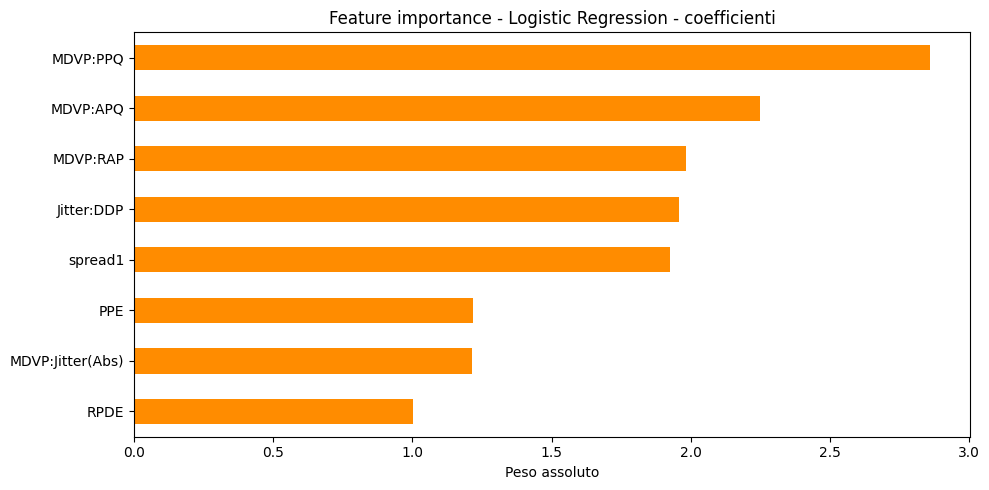

In [42]:
lr_imp = pd.Series(lr_gs.best_estimator_['lr'].coef_[0], index=X_train.columns)
lr_imp.abs().nlargest(8).sort_values().plot(kind='barh', color='darkorange', figsize=(10, 5))
plt.title('Feature importance - Logistic Regression - coefficienti')
plt.xlabel('Peso assoluto')
plt.tight_layout()
plt.show()

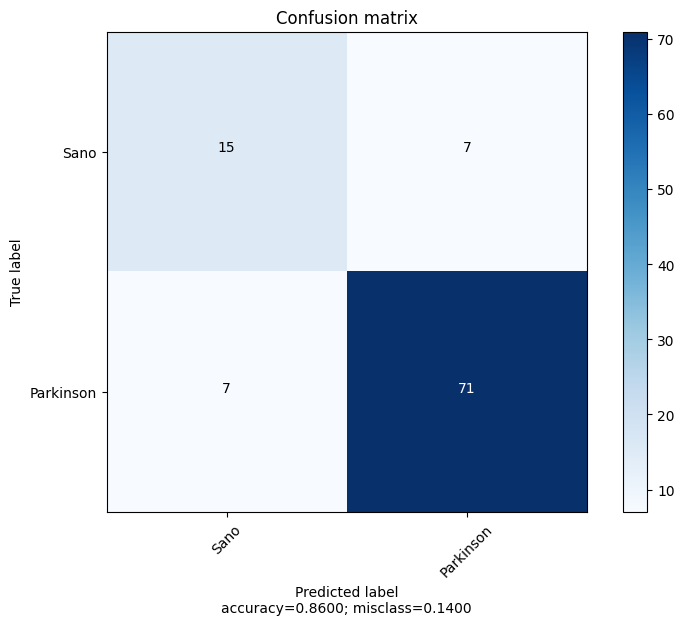

In [43]:
y_pred = lr_gs.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [44]:
pred = lr_gs.predict(X_val)
print(classification_report(y_val, pred, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.68      0.68      0.68        22
   Parkinson       0.91      0.91      0.91        78

    accuracy                           0.86       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.86      0.86      0.86       100



In [45]:
lr_mse = mean_squared_error(y_val, lr_gs.predict(X_val))
print('MSE Logistic Regression: {:.4f}'.format(lr_mse))

MSE Logistic Regression: 0.1400


# Support Vector Machine (SVM)

La **Support Vector Machine** è un algoritmo di classificazione che cerca il **margine massimo** di separazione tra le classi nello spazio delle features. Tramite il **kernel trick**, è possibile operare in spazi ad alta dimensionalità in modo implicito, rendendo SVM efficace anche con dati non linearmente separabili.

In [46]:
from sklearn.svm import SVC

std_svm = Pipeline([
    ('std', StandardScaler()),
    ('svm', SVC())
])

parameters = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.01, 0.1, 1, 10, 100], # 0.01: modello morbido (più tolleranza), 100: molto rigido (overfitting risk)
    'svm__gamma': ['scale', 'auto'],
}

svm_gs = GridSearchCV(std_svm, parameters, cv=5, n_jobs=-1,
                      return_train_score=True, scoring='f1')
svm_gs.fit(X_train, y_train)
print('Finish SVM Grid Search')

Finish SVM Grid Search


In [47]:
print('Best parameters:', svm_gs.best_params_)
print('Best score: {:.4f}%'.format(round(svm_gs.best_score_ * 100, 4)))

Best parameters: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best score: 97.2123%


In [48]:
confidence = 95
lower, upper = confidence_interval(len(X_val), svm_gs.score(X_val, y_val), confidence)
print('Intervallo di confidenza {}%: \nPmin = {:.4f}%\nPmax = {:.4f}%'.format(confidence, lower*100, upper*100))

Intervallo di confidenza 95%: 
Pmin = 93.0575%
Pmax = 99.4667%


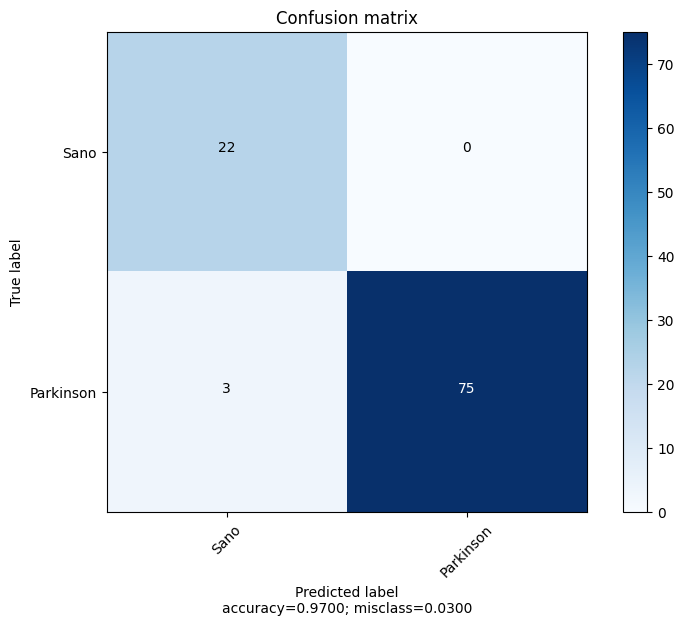

In [49]:
y_pred = svm_gs.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [50]:
pred = svm_gs.predict(X_val)
print(classification_report(y_val, pred, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.88      1.00      0.94        22
   Parkinson       1.00      0.96      0.98        78

    accuracy                           0.97       100
   macro avg       0.94      0.98      0.96       100
weighted avg       0.97      0.97      0.97       100



In [51]:
svm_mse = mean_squared_error(y_val, svm_gs.predict(X_val))
print('MSE SVM: {:.4f}'.format(svm_mse))

MSE SVM: 0.0300


# Random Forest

Il **Random Forest** è un algoritmo di ensemble learning che costruisce un insieme (foresta) di alberi decisionali, ciascuno addestrato su un sottoinsieme casuale dei dati e delle features. La predizione finale è ottenuta per **voto di maggioranza** tra tutti gli alberi. Questa tecnica riduce la varianza rispetto al singolo albero decisionale, ottenendo modelli robusti all'overfitting e con ottima generalizzazione.

In [52]:
from sklearn.ensemble import RandomForestClassifier

rfc = Pipeline([
    ('std', StandardScaler()),
    ('rfc', RandomForestClassifier(n_jobs=-1, random_state=3))
])

parameters = {
    'rfc__n_estimators': [100, 200, 300],
    'rfc__max_depth': [2, 4, 6, 8, 10, None],
    'rfc__min_samples_leaf': [1, 2, 4],
    'rfc__min_samples_split': [2, 5, 10],
}

rfc_gs = GridSearchCV(rfc, parameters, cv=5, n_jobs=-1, return_train_score=True, scoring='f1')
rfc_gs.fit(X_train, y_train)
print('Random Forest GridSearch finish')

Random Forest GridSearch finish


In [53]:
print('Best parameters:', rfc_gs.best_params_)
print('Best score: {:.4f}%'.format(round(rfc_gs.best_score_*100, 4)))

Best parameters: {'rfc__max_depth': 8, 'rfc__min_samples_leaf': 1, 'rfc__min_samples_split': 2, 'rfc__n_estimators': 200}
Best score: 96.4346%


In [54]:
confidence = 95
lower, upper = confidence_interval(len(X_val), rfc_gs.score(X_val, y_val), confidence)
print('Intervallo di confidenza {}%: \nPmin = {:.4f}%\nPmax = {:.4f}%'.format(confidence, lower*100, upper*100))

Intervallo di confidenza 95%: 
Pmin = 93.1324%
Pmax = 99.4880%


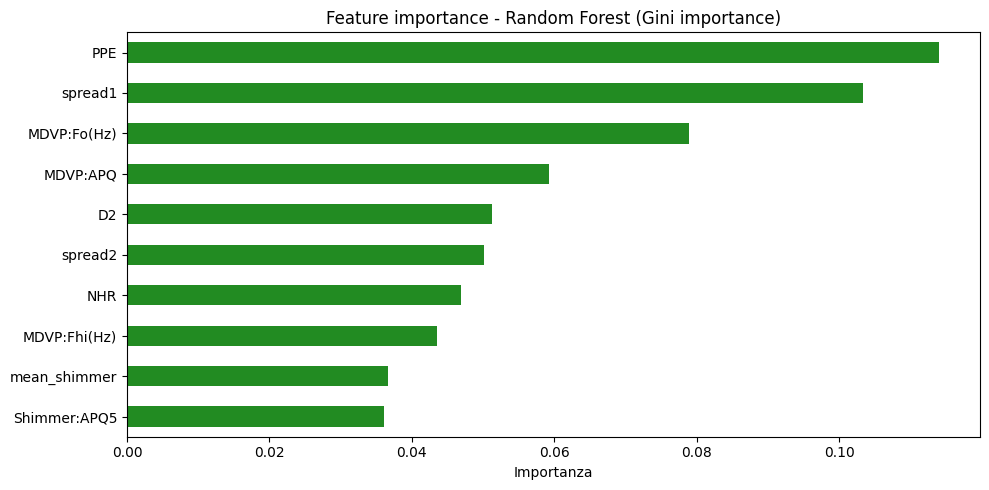

In [55]:
rf_imp = pd.Series(
    rfc_gs.best_estimator_['rfc'].feature_importances_,
    index=X_train.columns
)
rf_imp.nlargest(10).sort_values().plot(kind='barh', color='forestgreen', figsize=(10, 5))
plt.title('Feature importance - Random Forest (Gini importance)')
plt.xlabel('Importanza')
plt.tight_layout()
plt.show()

Il Random Forest, identifica `spread1`, `PPE` e `RPDE` come le features più informative per la classificazione del Parkinson, confermando i risultati della letteratura scientifica che indica le misure di complessità non lineare come i biomarcatori vocali più discriminanti.

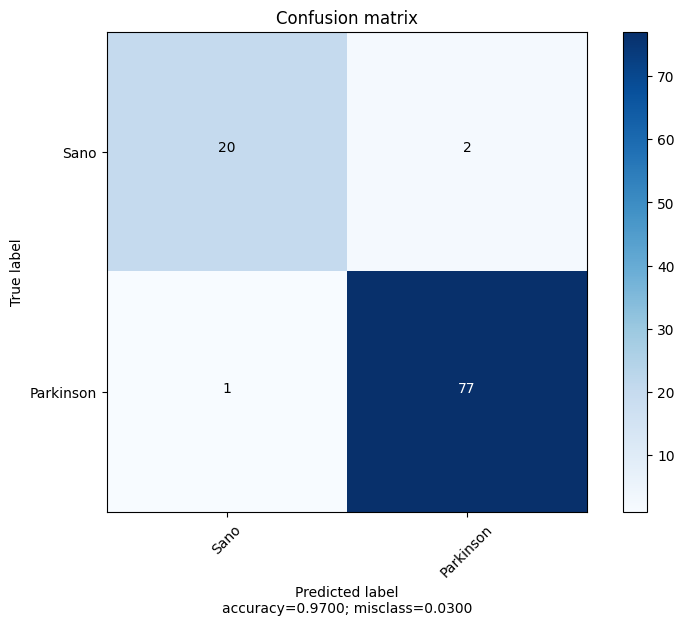

In [56]:
y_pred = rfc_gs.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [57]:
pred = rfc_gs.predict(X_val)
print(classification_report(y_val, pred, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.95      0.91      0.93        22
   Parkinson       0.97      0.99      0.98        78

    accuracy                           0.97       100
   macro avg       0.96      0.95      0.96       100
weighted avg       0.97      0.97      0.97       100



In [58]:
rfc_mse = mean_squared_error(y_val, rfc_gs.predict(X_val))
print('MSE Random Forest: {:.4f}'.format(rfc_mse))

MSE Random Forest: 0.0300


# XGBoost

**XGBoost (eXtreme Gradient Boosting)** è un algoritmo di ensemble basato su **gradient boosting** che costruisce gli alberi in modo sequenziale, ognuno dei quali corregge gli errori del precedente. Particolarmente efficace in contesti complessi, come nel progetto in campo biomedico, grazie alla sua capacità di gestire dati con molte features e relazioni non lineari.

In [59]:
from xgboost import XGBClassifier

std_xgb = Pipeline([
    ('std', StandardScaler()),
    ('xgb', XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False))
])

parameters = {
    'xgb__eta': [0.01, 0.1, 0.3],
    'xgb__max_depth': [3, 6, 9],
    'xgb__n_estimators': [100, 200, 300],
    'xgb__alpha': [0.0001, 0.001, 0.01]
}

xgb_gs = GridSearchCV(std_xgb, parameters, cv=5, n_jobs=-1,return_train_score=True, scoring='f1')
xgb_gs.fit(X_train, y_train)
print('Grid Search XGBoost finish')

Grid Search XGBoost finish


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:27:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [60]:
print('Best parameters:', xgb_gs.best_params_)
print('Best score: {:.4f}%'.format(round(xgb_gs.best_score_ * 100, 4)))

Best parameters: {'xgb__alpha': 0.01, 'xgb__eta': 0.3, 'xgb__max_depth': 9, 'xgb__n_estimators': 200}
Best score: 97.1871%


In [61]:
confidence = 95
lower, upper = confidence_interval(len(X_val), xgb_gs.score(X_val, y_val), confidence)
print('Intervallo di confidenza {}%: \nPmin = {:.4f}%\nPmax = {:.4f}%'.format(confidence, lower*100, upper*100))

Intervallo di confidenza 95%: 
Pmin = 93.0954%
Pmax = 99.4775%


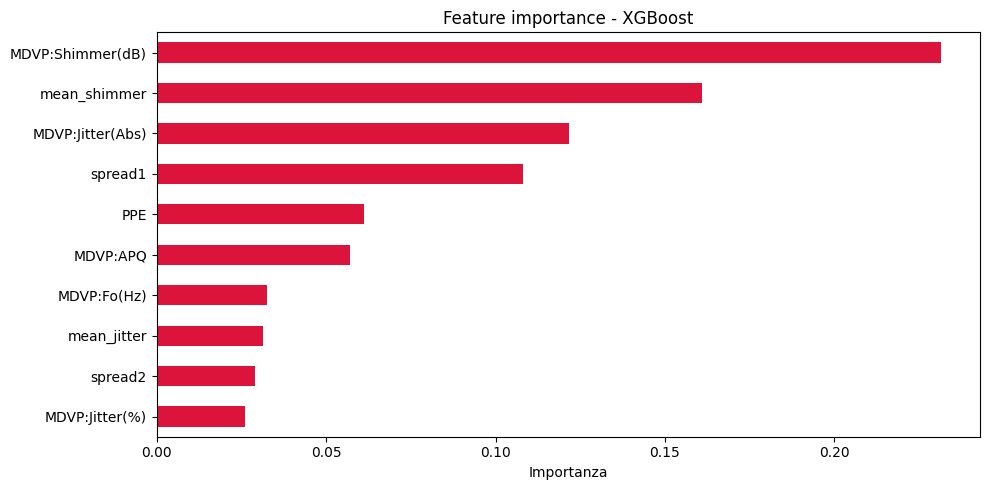

In [62]:
xgb_imp = pd.Series(
    xgb_gs.best_estimator_['xgb'].feature_importances_,
    index=X_train.columns
)
xgb_imp.nlargest(10).sort_values().plot(kind='barh', color='crimson', figsize=(10, 5))
plt.title('Feature importance - XGBoost')
plt.xlabel('Importanza')
plt.tight_layout()
plt.show()

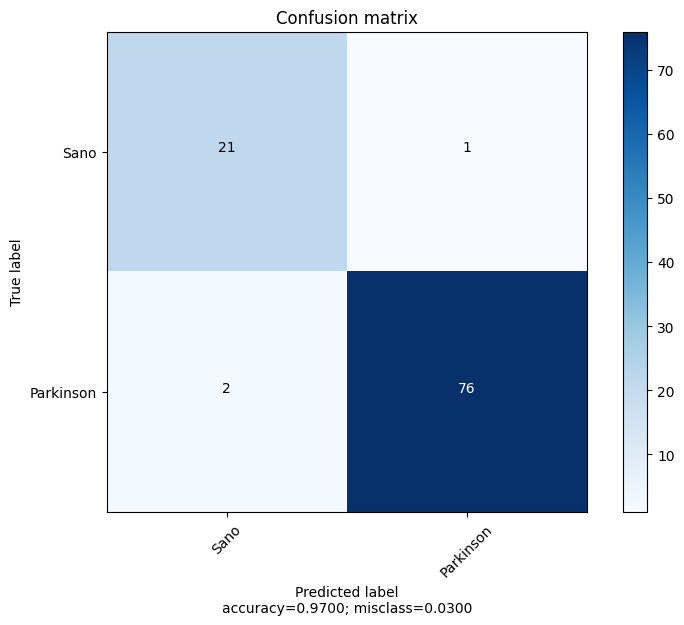

In [63]:
y_pred = xgb_gs.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [64]:
pred = xgb_gs.predict(X_val)
print(classification_report(y_val, pred, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.91      0.95      0.93        22
   Parkinson       0.99      0.97      0.98        78

    accuracy                           0.97       100
   macro avg       0.95      0.96      0.96       100
weighted avg       0.97      0.97      0.97       100



In [65]:
xgb_mse = mean_squared_error(y_val, xgb_gs.predict(X_val))
print('MSE XGBoost: {:.4f}'.format(xgb_mse))

MSE XGBoost: 0.0300


# Confronto tra i modelli

Confrontiamo le performance di tutti i modelli addestrati, sia in termini di accuracy che di F1-score e verifichiamo statisticamente se le differenze osservate sono significative.

Per il confronto statistico si utilizza il **test di McNemar** tramite l'approssimazione basata sull'MSE.

In [66]:
from sklearn.metrics import f1_score

models = {
    'Perceptron': perceptron_cv,
    'Perceptron Poly': poly_perceptron_cv,
    'Logistic Regression': lr_gs,
    'SVM': svm_gs,
    'Random Forest': rfc_gs,
    'XGBoost': xgb_gs,
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_val)
    acc = model.score(X_val, y_val)
    f1 = f1_score(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    results.append({'Modello': name, 'Accuracy': acc, 'F1-score': f1, 'MSE': mse})

results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False)
results_df

,Modello,Accuracy,F1-score,MSE
4,Random Forest,0.980892,0.980892,0.03
5,XGBoost,0.980645,0.980645,0.03
3,SVM,0.980392,0.980392,0.03
1,Perceptron Poly,0.967320,0.967320,0.05
2,Logistic Regression,0.910256,0.910256,0.14
0,Perceptron,0.820144,0.820144,0.25


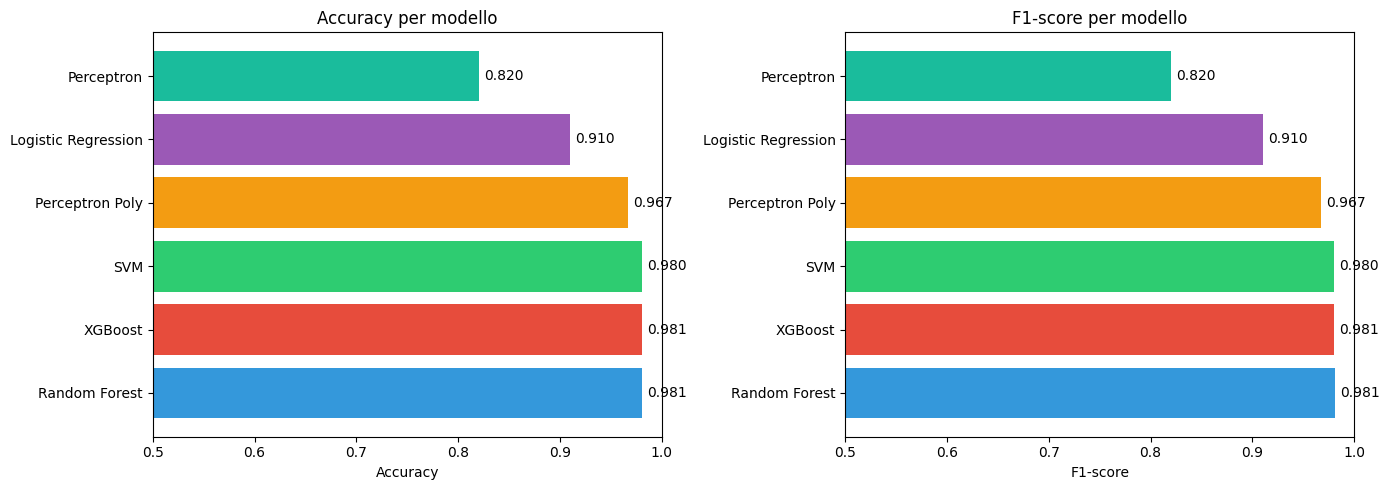

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

axes[0].barh(results_df['Modello'], results_df['Accuracy'], color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy per modello')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center')

axes[1].barh(results_df['Modello'], results_df['F1-score'], color=colors)
axes[1].set_xlabel('F1-score')
axes[1].set_title('F1-score per modello')
axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['F1-score']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

## Confronto statistico tra modelli

Per verificare se le differenze di performance tra i modelli sono statisticamente significative, utilizziamo un **test basato sull'MSE** (approssimazione al test di McNemar). Dati due MSE $e_1$ e $e_2$, l'intervallo di confidenza al 95% per la differenza è:

$$\Delta \pm 1.96 \cdot \sqrt{\frac{e_1 + e_2 - (e_1 - e_2)^2}{n}}$$

Se l'intervallo contiene 0, i due modelli **non sono significativamente diversi**.

In [68]:
def model_comparison(e1, e2, n=None):
    if n is None:
        n = len(X_val)
    delta = e1-e2
    margin = 1.96*np.sqrt((e1+e2-(e1-e2)**2) / n)
    return [delta-margin, delta+margin]

### SVM vs XGBoost

In [69]:
print('Intervallo SVM vs XGBoost: {}'.format(np.round(model_comparison(svm_mse, xgb_mse), 4)))

Intervallo SVM vs XGBoost: [-0.048  0.048]


### XGBoost vs Random Forest

In [70]:
print('Intervallo XGBoost vs Random Forest: {}'.format(np.round(model_comparison(xgb_mse, rfc_mse), 4)))

Intervallo XGBoost vs Random Forest: [-0.048  0.048]


### Perceptron vs Logistic Regression

In [71]:
print('Intervallo Perceptron vs Logistic Regression: {}'.format(np.round(model_comparison(perc_mse, lr_mse), 4)))

Intervallo Perceptron vs Logistic Regression: [-0.0105  0.2305]


### Perceptron vs XGBoost

In [72]:
print('Intervallo Perceptron vs XGBoost: {}'.format(np.round(model_comparison(perc_mse, xgb_mse), 4)))

Intervallo Perceptron vs XGBoost: [0.1257 0.3143]


I modelli ensemble (**Random Forest** e **XGBoost**) tendono ad ottenere i risultati migliori su questo dataset grazie alla loro capacità di catturare relazioni non lineari tra le features vocali, come precedentemente accennato.

I modelli lineari (**Perceptron** e **Logistic Regression**) hanno performance più modeste, probabilmente a causa della natura intrinsecamente non lineare delle relazioni tra le misurazioni complesse biomediche.

La **SVM con kernel RBF** si posiziona in una posizione intermedia, sfruttando la trasformazione non lineare implicita per ottenere buone performance.

# Neural Network

Come ultimo modello, addestriamo una **rete neurale artificiale** con architettura feedforward (Multi-Layer Perceptron). Le reti neurali sono in grado di apprendere rappresentazioni gerarchiche delle features e catturare relazioni altamente non lineari.

In [73]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].plot(hist['epoch'], hist['loss'], label='Train Loss')
    axes[0].plot(hist['epoch'], hist['val_loss'], label='Val Loss')
    axes[0].set_ylim([0, 1])
    axes[0].legend()
    axes[0].set_title('Loss durante il training')

    acc_key = 'accuracy' if 'accuracy' in hist.columns else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in hist.columns else 'val_acc'

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].plot(hist['epoch'], hist[acc_key], label='Train Accuracy')
    axes[1].plot(hist['epoch'], hist[val_acc_key], label='Val Accuracy')
    axes[1].set_ylim([0.4, 1])
    axes[1].legend()
    axes[1].set_title('Accuracy durante il training')

    plt.tight_layout()
    plt.show()

In [74]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

scaler_X = StandardScaler()
std_X_train = scaler_X.fit_transform(X_train.astype(float))
std_X_val = scaler_X.transform(X_val.astype(float))

class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch%100 == 0:
            print('')
        print('.', end='')

In [75]:
def nn_build_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model


model = nn_build_model(std_X_train.shape[1])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [76]:
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    std_X_train, y_train,
    validation_split=0.2,
    batch_size=16,
    epochs=200,
    verbose=0,
    callbacks=[PrintDot(), early_stopping]
)


.............................................

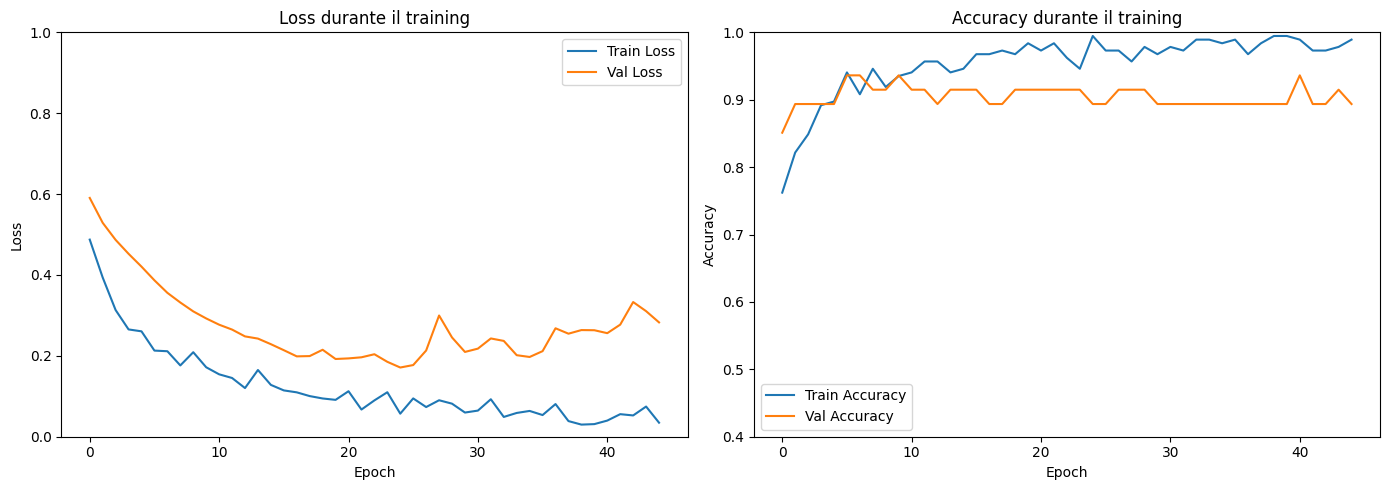

In [77]:
plot_history(history)

In [78]:
loss, acc = model.evaluate(std_X_val, y_val, batch_size=16)
print(f'\nLoss: {loss:.4f} - Accuracy: {acc:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9600 - loss: 0.1041 

Loss: 0.1041 - Accuracy: 0.9600


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


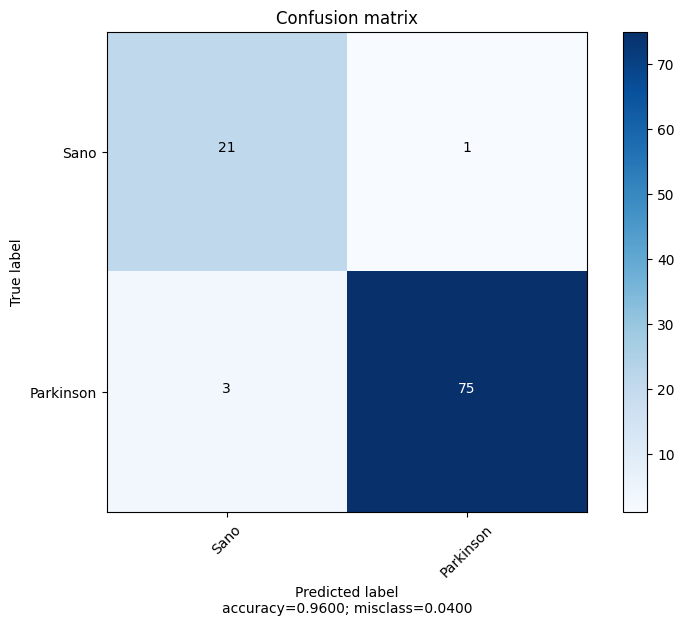

In [79]:
y_pred_nn = (model.predict(std_X_val) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_val, y_pred_nn)
plot_confusion_matrix(cm, target_names=['Sano', 'Parkinson'], normalize=False)

In [80]:
print(classification_report(y_val, y_pred_nn, target_names=['Sano', 'Parkinson']))

              precision    recall  f1-score   support

        Sano       0.88      0.95      0.91        22
   Parkinson       0.99      0.96      0.97        78

    accuracy                           0.96       100
   macro avg       0.93      0.96      0.94       100
weighted avg       0.96      0.96      0.96       100



# Conclusioni

In questo progetto abbiamo sviluppato un sistema di **classificazione binaria** per la **diagnosi del Morbo di Parkinson** a partire da **misurazioni biomediche della voce**, seguendo questo workflow:

1. **Data Exploration**: il dataset presenta un leggero sbilanciamento (75% Parkinson vs 25% sano), e le features mostrano una notevole eterogeneità di scala. Le misure di jitter, shimmer e le features di complessità non lineare (RPDE, PPE, spread1) si sono rivelate le più discriminanti.

2. **Data Cleaning**: rimossi outlier fisicamente inconsistenti nelle misure di frequenza fondamentale. l dataset non presentava valori nulli.

3. **Feature Engineering**: introdotte tre nuove features aggregate (mean_jitter, mean_shimmer, freq_range) che sintetizzano l'informazione di misure altamente correlate.

4. **Modelli addestrati e confrontati**:
   - Perceptron (lineare e polinomiale): performance più limitate, penalizzate dalla **non linearità** del problema.
   - Logistic Regression: buona interpretabilità, performance moderate.
   - SVM: ottima performance grazie alla trasformazione non lineare implicita.
   - Random Forest: elevata performance con ottima interpretabilità tramite feature importance.
   - XGBoost: tra le performance più alte, robusto e gestisce bene l'eterogeneità delle features.
   - Neural Network - MLP: ottima performance, particolarmente efficace nel catturare relazioni non lineari complesse.

5. **Risultato principale**: i modelli e la rete neurale raggiungono accuracy elevate, confermando che le misurazioni vocali sono **biomarcatori efficaci** per la diagnosi del Parkinson.